# Computational Performance & Scaling Benchmarks


Benchmarks the execution time and computational scaling of the library for both Continuous Wave (CW) and time-resolved EPR simulations. It measures performance across increasing system sizes (number of spins, batch sizes) and evaluates the efficiency of different simulation engines (Kinetic, Rotating Wave Approximation, and Propagator methods).

In [3]:
%load_ext autoreload
%autoreload 2

import sys
import os
import random
import typing as tp
import math
from importlib import reload
import functools
import pathlib

import csv
import json

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


import time
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Union, Tuple, List
from mars import spin_model, spectra_manager, mesher, constants
import mars

from sample_creators_local import (create_electron_nucleus, create_electron_anisotropic_chain, create_heterospin_connected_to_Co,
                                   create_heterospin_connected_to_Co_high_values,
                                   create_electron_DE_chain, create_electron_batch_size, create_electron_batch_size_2N,
                                   create_relaxation_batch_size, create_relaxation_coupled
                                  )
from sample_relaxation_initial import (set_relaxation_and_initial_channels, set_relaxation_and_initial_channels_batches)

from saving_benchmarks import save_benchmark_results, load_benchmark_results
from bencmarking import (
    benchmark_several_configurations, compare_benchmarks, plot_benchmark_comparison,
    time_spectrum_calculation_full_pipeline, time_spectrum_calculation_full_pipeline_freqdep, time_spectrum_calculation_full_pipeline_timedep)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

In [5]:
def save_csv(path: tp.Union[str, pathlib.Path], out_dict: tp.Dict[str, float], meta=tp.Dict[str, str]):
    with open(path, "w", newline="") as f:
        f.write(f'# {json.dumps(meta)}\n')

        fieldnames = out_dict[0].keys()
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(out_dict)

In [16]:
import matplotlib.pyplot as plt
dtype = torch.float32
device = torch.device("cpu")

mesh = mars.mesher.DelaunayMesh(initial_grid_frequency=25, interpolation_grid_frequency=20, interpolator="barycentric", dtype=dtype, device=device, interpolate=False)

In [17]:
freq = torch.tensor(9.8 * 1e9, dtype=dtype, device=device)
temperature = torch.tensor(300.0, dtype=dtype, device=device)
n_field_points = 1000

### 1. S = 1/2 electron spin connected with nuclei spins

In [6]:
sample_1 = create_electron_nucleus(mesh=mesh, num_nuclei=3, device=device, dtype=dtype, disable_randomness=True)

field_range = (0.33, 0.37)
n_field_points = 1000

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_field_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_1,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_1, fields=fields)

/home/arkady/SpinSpec/MarS-main_2026_03_28/mars/spectra_manager/spectra_manager.py:1598: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("resonance_parameter", torch.tensor(resonance_parameter, device=device, dtype=dtype))
/home/arkady/SpinSpec/MarS-main_2026_03_28/mars/population/populators/core.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "init_temperature", torch.tensor(init_temperature, device=device, dtype=dtype)


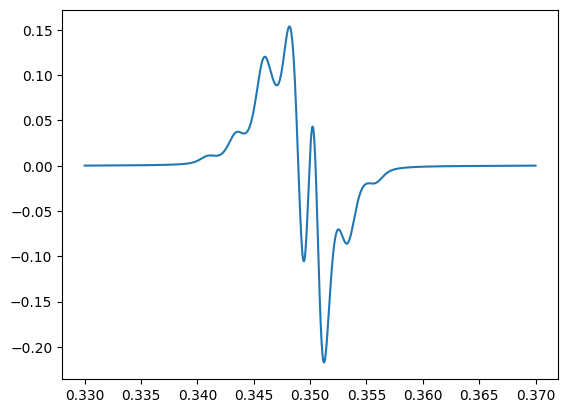

In [7]:
plt.plot(fields.cpu(), out.cpu())

In [ ]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_1_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1/2 connected with nuclei spins"}

for num_nuclei in range(4):
    sample_function = functools.partial(create_electron_nucleus, num_nuclei=num_nuclei)
    
    result = time_spectrum_calculation_full_pipeline(
        sample_creation_func=sample_function,
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
        freq=freq, field_range=field_range, n_points=n_field_points, temperature=temperature,
        computational_details=computational_details,
        n_warmup=5, n_iterations=100
    )
    time_calculation_results.append({"num_nuclei": num_nuclei, "mean": result[0], "std": result[1]})
save_csv(path, time_calculation_results, meta)

In [138]:
time_calculation_results

[{'num_nuclei': 0, 'mean': 7.160702150031284, 'std': 0.36845838463368846},
 {'num_nuclei': 1, 'mean': 13.846442679978281, 'std': 2.381012330963365},
 {'num_nuclei': 2, 'mean': 54.92969053003435, 'std': 14.595589969940617},
 {'num_nuclei': 3, 'mean': 2635.29074692, 'std': 51.21130573223254}]

In [165]:
time_calculation_results

[{'num_electrons': 1, 'mean': 6.288360860053217, 'std': 0.3978235738522875},
 {'num_electrons': 2, 'mean': 15.346856960240984, 'std': 0.9910018053435514},
 {'num_electrons': 3, 'mean': 44.38929066978744, 'std': 2.5226960219267593},
 {'num_electrons': 4, 'mean': 185.8690129902243, 'std': 10.356632358583688},
 {'num_electrons': 5, 'mean': 1258.565286999874, 'std': 42.933434745793996},
 {'num_electrons': 6, 'mean': 12549.749649840234, 'std': 196.64850524927064}]

In [21]:
time_calculation_results

[{'num_nuclei': 0, 'mean': 8.252636199983954, 'std': 0.5200191606178057},
 {'num_nuclei': 1, 'mean': 13.749212599998373, 'std': 1.223379624246718},
 {'num_nuclei': 2, 'mean': 57.60928579999245, 'std': 13.339112009244166},
 {'num_nuclei': 3, 'mean': 2639.3588183999896, 'std': 37.510161415138796}]

### 2. S = 1/2 electron spin connected with two nuceli spin. Comparison the speed over batch size

In [8]:
batch_size=2
sample_2 = create_electron_batch_size_2N(mesh=mesh, batch_size=batch_size, device=device, dtype=dtype)

field_range = (0.33, 0.37)

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_field_points,
            device=device,
            dtype=dtype
        ).expand(batch_size, -1)

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_2,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_2, fields=fields)

/home/arkady/SpinSpec/MarS-main_2026_03_28/mars/spin_model.py:2171: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  width = torch.tensor(width, device=device, dtype=dtype)


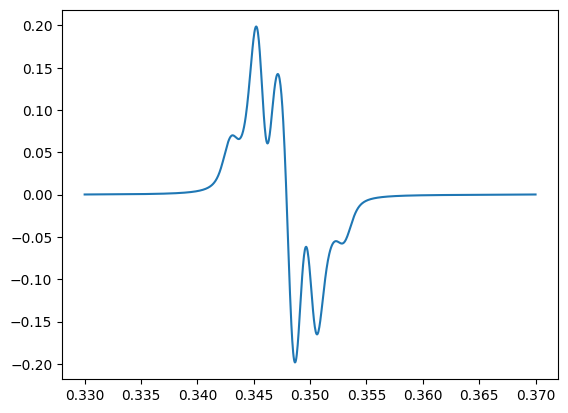

In [9]:
plt.plot(fields[1].cpu(), out[1].cpu())

In [19]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_2_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1/2 connected with two nuclei spin in batch computations"}

for batch_size in range(1, 15):
    sample_function = functools.partial(create_electron_batch_size_2N, batch_size=batch_size)

    result = time_spectrum_calculation_full_pipeline(
        sample_creation_func=sample_function,
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
        freq=freq, field_range=field_range, n_points=n_field_points, temperature=temperature,
        computational_details=computational_details,
        n_warmup=5, n_iterations=100,
    )
    time_calculation_results.append({"batch_size": batch_size, "mean": result[0] / batch_size, "std": result[1] / math.sqrt(batch_size)})
save_csv(path, time_calculation_results, meta)

In [ ]:
time_calculation_results

### 3. The chain of electrons S=1/2 connected to each other by exhcange interaction

In [142]:
sample_3 = create_electron_anisotropic_chain(mesh=mesh, num_electrons=4, device=device, dtype=dtype, disable_randomness=True)

field_range = (0.27, 0.38)
n_field_points = 1000

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_field_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_3,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_3, fields=fields)

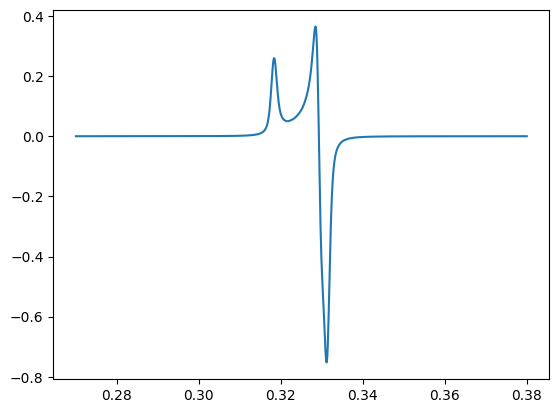

In [143]:
plt.plot(fields, out)

In [149]:
# Float 32 Failed to coverage under float 32 with n_electrons > 5

if torch.cuda.is_available():
    torch.cuda.empty_cache()

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_3_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1/2 connected with other spin 1/2 in chain"}

for num_electrons in range(1, 5):
    sample_function = functools.partial(create_electron_anisotropic_chain, num_electrons=num_electrons)

    result = time_spectrum_calculation_full_pipeline(
        sample_creation_func=sample_function,
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
        freq=freq, field_range=field_range, n_points=n_field_points, temperature=temperature,
        computational_details=computational_details,
        n_warmup=5, n_iterations=100,
    )
    time_calculation_results.append({"num_electrons": num_electrons, "mean": result[0], "std": result[1]})
save_csv(path, time_calculation_results, meta)

/home/arkady/SpinSpec/MarS-main_2026_03_28/mars/res_field_algorithm.py:635: UserWarning: There are no resonance in the interval
  warnings.warn("There are no resonance in the interval")


In [150]:
time_calculation_results

[{'num_electrons': 1, 'mean': 5.471382450486999, 'std': 2.434784415453325},
 {'num_electrons': 2, 'mean': 7.432332720127306, 'std': 1.5951492024240355},
 {'num_electrons': 3, 'mean': 12.328208109538537, 'std': 3.1376958128595587},
 {'num_electrons': 4, 'mean': 13.372368610216654, 'std': 2.3202623783861256}]

### 4. The chain of electrons S=1/2 connected to each other by dipolar interaction

In [27]:
sample_4 = create_electron_DE_chain(mesh=mesh, num_electrons=4, device=device, dtype=dtype)

field_range = (0.33, 0.37)
n_field_points = 1000

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_field_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_4,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_4, fields=fields)

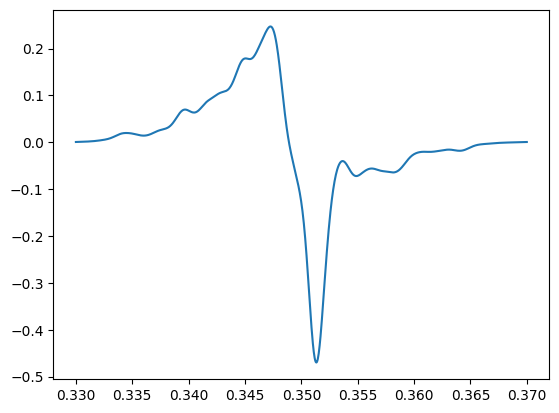

In [28]:
plt.plot(fields, out)

In [38]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_4_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1/2 connected with other spin 1/2 in chain with DE interaction"}

for num_electrons in range(1, 6):
    sample_function = functools.partial(create_electron_DE_chain, num_electrons=num_electrons)

    result = time_spectrum_calculation_full_pipeline(
        sample_creation_func=sample_function,
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
        freq=freq, field_range=field_range, n_points=n_field_points, temperature=temperature,
        computational_details=computational_details,
        n_warmup=5, n_iterations=100,
    )
    time_calculation_results.append({"num_electrons": num_electrons, "mean": result[0], "std": result[1]})
save_csv(path, time_calculation_results, meta)

In [39]:
time_calculation_results

[{'num_electrons': 1, 'mean': 7.035982340003102, 'std': 0.534283475136881},
 {'num_electrons': 2, 'mean': 15.023607619991708, 'std': 1.3379499360851486},
 {'num_electrons': 3, 'mean': 29.26893503998599, 'std': 3.5270588136698415},
 {'num_electrons': 4, 'mean': 79.20850258995415, 'std': 12.006216495600905},
 {'num_electrons': 5, 'mean': 171.79807118998724, 'std': 11.025696203331025}]

### 4.1. Heterospin with small D/E and exchange parmaters
The system of S=3/2 with small D/E parameters connected to radical spins with S=1/2 by small exchange interaction

In [20]:
sample_4_1 = create_heterospin_connected_to_Co(mesh=mesh, num_electrons=4, device=device, dtype=dtype, disable_randomness=True)

field_range = (0.0, 1.0)
n_field_points = 1000

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_field_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_4_1,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_4_1, fields=fields)

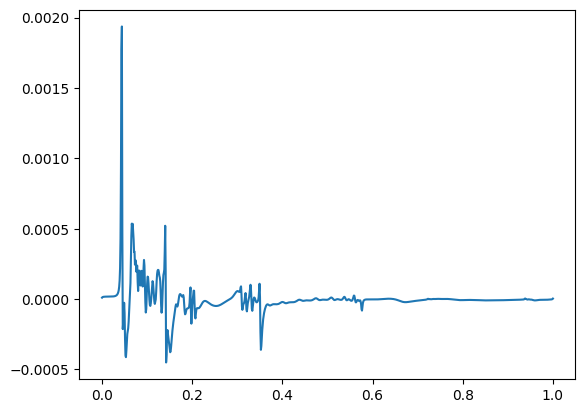

In [17]:
plt.plot(fields, out)

In [ ]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_4_1_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 3/2 with D/E connected with other spin 1/2 in chain with J interaction"}

for num_electrons in range(1, 2):
    sample_function = functools.partial(create_heterospin_connected_to_Co, num_electrons=num_electrons)

    result = time_spectrum_calculation_full_pipeline(
        sample_creation_func=sample_function,
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
        freq=freq, field_range=field_range, n_points=n_field_points, temperature=temperature,
        computational_details=computational_details,
        n_warmup=1, n_iterations=5,
    )
    time_calculation_results.append({"num_electrons": num_electrons, "mean": result[0], "std": result[1]})
save_csv(path, time_calculation_results, meta)

### 4.2. Heterospin with high D/E and exchange parmaters
The system of S=3/2 with high D/E parameters connected to radical spins with S=1/2 by high exchange interaction

In [ ]:
sample_4_2 = create_heterospin_connected_to_Co_high_values(mesh=mesh, num_electrons=3, device=device, dtype=dtype, disable_randomness=True)

field_range = (0.0, 1.0)
n_field_points = 1000

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_field_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_4_2,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_4_2, fields=fields)

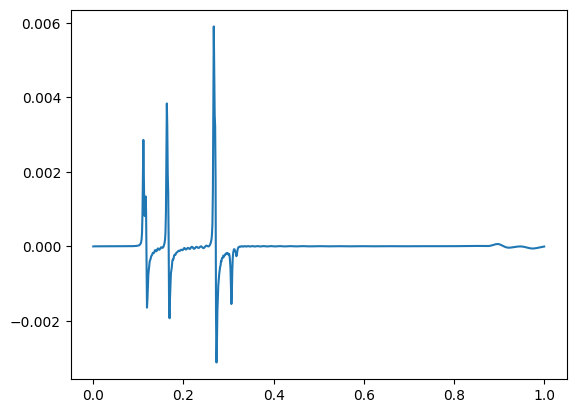

In [15]:
plt.plot(fields, out)

In [ ]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_4_2_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 3/2 with D/E connected with other spin 1/2 in chain with J interaction"}

for num_electrons in range(1, 2):
    sample_function = functools.partial(create_heterospin_connected_to_Co_high_values, num_electrons=num_electrons)

    result = time_spectrum_calculation_full_pipeline(
        sample_creation_func=sample_function,
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
        freq=freq, field_range=field_range, n_points=n_field_points, temperature=temperature,
        computational_details=computational_details,
        n_warmup=1, n_iterations=5,
    )
    time_calculation_results.append({"num_electrons": num_electrons, "mean": result[0], "std": result[1]})
save_csv(path, time_calculation_results, meta)

# Time Resolved EPR Time comparison

### 5. System of S = 1/2 coupled by small exchange interaction

In [9]:
sample_5 = create_relaxation_coupled(mesh=mesh, num_electrons=1, device=device, dtype=dtype)
context = set_relaxation_and_initial_channels(sample_5, num_contexts=3)


field_range = (0.27, 0.38)
time_points = 200
time_range = (0.0, 1.0 * 1e-4)
time_simulations = torch.linspace(
            time_range[0],
            time_range[1],
            time_points,
            device=device,
            dtype=dtype
        )

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_field_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

creator = spectra_manager.CoupledTimeSpectra(
    context=context,
    freq=freq,
    harmonic=0,
    sample=sample_5,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_5, fields=fields, time=time_simulations)

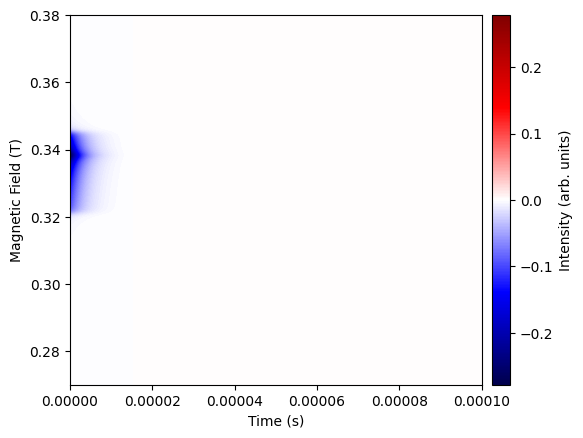

In [10]:
mars.visualization.time_resolved.plot_2d_timeresolved(fields, time_simulations, out)

In [251]:
creator = spectra_manager.DensityTimeSpectra(
    populator="propagator",
    hamiltonian_mode = "secular",
    context=context,
    freq=freq,
    harmonic=0,
    sample=sample_5,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_5, fields=fields, time=time_simulations)

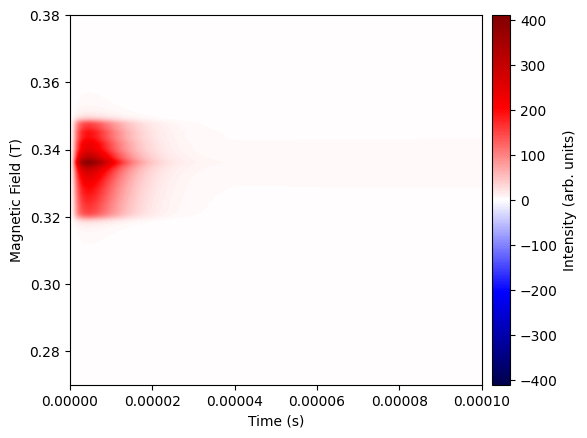

In [235]:
mars.visualization.time_resolved.plot_2d_timeresolved(fields, time_simulations, out)

### 5.1. Kinetic Creator

In [11]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_5_kinetic_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1/2 connected with other spin 1/2 in chain with J interaction and anisotropy"}

for num_electrons in range(1, 5):
    sample_function = functools.partial(create_relaxation_coupled, num_electrons=num_electrons)
    context_function = functools.partial(set_relaxation_and_initial_channels, num_contexts=1)
    
    result = time_spectrum_calculation_full_pipeline_timedep(
        sample_creation_func=sample_function,
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype,},
        freq=freq, field_range=field_range, time_range=time_range,
        n_points=n_field_points, n_points_time=time_points,
        context=context_function,
        temperature=temperature,
        computational_details=computational_details,
        n_warmup=5, n_iterations=100,
    )
    time_calculation_results.append({"num_electrons": num_electrons, "mean": result[0], "std": result[1]})
save_csv(path, time_calculation_results, meta)

In [12]:
time_calculation_results

[{'num_electrons': 1, 'mean': 14.901266999981999, 'std': 0.8563723570058083},
 {'num_electrons': 2, 'mean': 39.79889979998234, 'std': 12.042885920137035},
 {'num_electrons': 3, 'mean': 105.69431819999863, 'std': 10.355534518878738},
 {'num_electrons': 4, 'mean': 885.6834731199956, 'std': 102.35686664996221}]

### 5.2. RWA

In [54]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_5_RWA_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1/2 connected with other spin 1/2 in chain with J interaction and anisotropy"}

for num_electrons in range(1, 3):
    sample_function = functools.partial(create_relaxation_coupled, num_electrons=num_electrons)
    context_function = functools.partial(set_relaxation_and_initial_channels, num_contexts=3)
    
    result = time_spectrum_calculation_full_pipeline_timedep(
        sample_creation_func=sample_function,
        creator_kwargs={"populator": "rwa"},
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype,},
        freq=freq, field_range=field_range, time_range=time_range,
        n_points=n_field_points, n_points_time=time_points,
        context=context_function,
        temperature=temperature,
        computational_details=computational_details,
        n_warmup=2, n_iterations=5,
        simulation_cls=spectra_manager.DensityTimeSpectra,
    )
    time_calculation_results.append({"num_electrons": num_electrons, "mean": result[0], "std": result[1]})
    save_csv(path, time_calculation_results, meta)

In [55]:
time_calculation_results

[{'num_electrons': 1, 'mean': 160.39653999978327, 'std': 7.443070945642955},
 {'num_electrons': 2, 'mean': 285.2770800003782, 'std': 10.853420906094982}]

### 5.3. PROPAGATOR

In [59]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_5_propagator_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1/2 connected with other spin 1/2 in chain with J interaction and anisotropy"}

for num_electrons in range(1, 3):
    sample_function = functools.partial(create_relaxation_coupled, num_electrons=num_electrons)
    context_function = functools.partial(set_relaxation_and_initial_channels, num_contexts=3)
    
    result = time_spectrum_calculation_full_pipeline_timedep(
        sample_creation_func=sample_function,
        creator_kwargs={"populator": "propagator", "hamiltonian_mode": "direct"},
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype,},
        freq=freq, field_range=field_range, time_range=time_range,
        n_points=n_field_points, n_points_time=time_points,
        context=context_function,
        temperature=temperature,
        computational_details=computational_details,
        n_warmup=2, n_iterations=5,
        simulation_cls=spectra_manager.DensityTimeSpectra,
    )
    
    time_calculation_results.append({"num_electrons": num_electrons, "mean": result[0], "std": result[1]})
    save_csv(path, time_calculation_results, meta)

In [60]:
time_calculation_results

[{'num_electrons': 1, 'mean': 1285.949160000746, 'std': 27.005526849722298},
 {'num_electrons': 2, 'mean': 37375.70826000083, 'std': 5821.112692298993}]

### 6. System of S=1 in batch computation

In [ ]:
batch_size = 2
sample_6 = create_relaxation_batch_size(mesh=mesh, batch_size=batch_size, device=device, dtype=dtype)
context = set_relaxation_and_initial_channels_batches(sample_6, num_contexts=3)


field_range = (0.27, 0.38)
time_points = 100
time_range = (0.0, 1.0 * 1e-4)
time_simulations = torch.linspace(
            time_range[0],
            time_range[1],
            time_points,
            device=device,
            dtype=dtype
        ).expand(batch_size, -1)

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_field_points,
            device=device,
            dtype=dtype
        ).expand(batch_size, -1)

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

creator = spectra_manager.DensityTimeSpectra(
    context=context,
    output_mode = "total",
    populator = "propagator",
    freq=freq,
    harmonic=0,
    sample=sample_6,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_6, fields=fields, time=time_simulations)

### 6.1. Kinetic Creator

In [ ]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_6_kinetic_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1 connected with other spin 1/2 in chain with J interaction and anisotropy"}

for batch_size in range(1, 3):
    sample_function = functools.partial(create_relaxation_batch_size, batch_size=batch_size)
    context_function = functools.partial(set_relaxation_and_initial_channels_batches, num_contexts=3)
    
    result = time_spectrum_calculation_full_pipeline_timedep(
        sample_creation_func=sample_function,
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype,},
        freq=freq, field_range=field_range, time_range=time_range,
        n_points=n_field_points, n_points_time=time_points,
        context=context_function,
        temperature=temperature,
        computational_details=computational_details,
        n_warmup=2, n_iterations=5,
    )
    time_calculation_results.append({"batch_size": batch_size, "mean": result[0] / batch_size, "std": result[1] / math.sqrt(batch_size)})
    save_csv(path, time_calculation_results, meta)

### 6.2. RWA

In [ ]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_6_RWA_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1 connected with other spin 1/2 in chain with J interaction and anisotropy"}

for batch_size in range(1, 3):
    sample_function = functools.partial(create_relaxation_batch_size, batch_size=batch_size)
    context_function = functools.partial(set_relaxation_and_initial_channels_batches, num_contexts=3)
    
    result = time_spectrum_calculation_full_pipeline_timedep(
        sample_creation_func=sample_function,
        creator_kwargs={"populator": "rwa"},
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype,},
        freq=freq, field_range=field_range, time_range=time_range,
        n_points=n_field_points, n_points_time=time_points,
        context=context_function,
        temperature=temperature,
        computational_details=computational_details,
        n_warmup=2, n_iterations=5,
        simulation_cls=spectra_manager.DensityTimeSpectra,
    )
    
    time_calculation_results.append({"batch_size": batch_size, "mean": result[0] / batch_size, "std": result[1] / math.sqrt(batch_size)})
    save_csv(path, time_calculation_results, meta)

### 6.3. PROPAGATOR

In [ ]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_6_propagator_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1 connected with other spin 1/2 in chain with J interaction and anisotropy"}

for batch_size in range(1, 3):
    sample_function = functools.partial(create_relaxation_batch_size, batch_size=batch_size)
    context_function = functools.partial(set_relaxation_and_initial_channels_batches, num_contexts=3)
    
    result = time_spectrum_calculation_full_pipeline_timedep(
        sample_creation_func=sample_function,
        creator_kwargs={"populator": "propagator", "hamiltonian_mode": "direct"},
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype,},
        freq=freq, field_range=field_range, time_range=time_range,
        n_points=n_field_points, n_points_time=time_points,
        context=context_function,
        temperature=temperature,
        computational_details=computational_details,
        n_warmup=2, n_iterations=5,
        simulation_cls=spectra_manager.DensityTimeSpectra,
    )
    
    time_calculation_results.append({"batch_size": batch_size, "mean": result[0] / batch_size, "std": result[1] / math.sqrt(batch_size)})
    save_csv(path, time_calculation_results, meta)